In [1]:
from functools import partial 
print = partial(print, flush=True) 

import matplotlib.pyplot as plt 
import numpy as np 
np.set_printoptions(legacy='1.25') 
import pandas as pd 
import seaborn as sns 
import statsmodels.api as sm 
from ISLP import confusion_table, load_data 
from ISLP.models import ModelSpec as MS 
from ISLP.models import summarize 
from sklearn.model_selection import train_test_split 
sns.set_theme() 
%matplotlib inline 
from ISLP.models import sklearn_sm 
from sklearn.model_selection import KFold, cross_validate 
np.random.seed(1234) 


In [3]:
file_path = 'palo-alto-house-prices.txt' 
data = np.loadtxt(file_path) 
print(data)


[17.8    4.2   14.     8.1   10.5    2.54   0.9    4.5    1.7    3.2
  7.39   7.     3.09   2.5    2.45   0.849  2.49   4.4    4.15   2.6
  5.65   1.5    3.49   2.32   2.05   2.19   1.9    3.7  ]


In [4]:
n_resamples = 1000 
alpha = 0.05 
sample_size = len(data) 
bootstrap_statistics = np.empty(n_resamples) 
for i in range(n_resamples): 
    # Resample with replacement 
    bootstrap_sample = np.random.choice(data, size=sample_size, replace=True) 
    # Calculate and store the statistic (e.g., mean) 
    bootstrap_statistics[i] = np.median(bootstrap_sample)


In [6]:
lower_percentile = 100 * (alpha / 2) 
upper_percentile = 100 * (1 - alpha / 2)
print(f"Lower: {lower_percentile}\nUpper: {upper_percentile}")

Lower: 2.5
Upper: 97.5


In [7]:
conf_interval_lower = np.percentile(bootstrap_statistics, lower_percentile) 
conf_interval_upper = np.percentile(bootstrap_statistics, upper_percentile) 
print(f"The 95% percentile bootstrap confidence interval is: [{conf_interval_lower:.2f}, {conf_interval_upper:.2f}]")


The 95% percentile bootstrap confidence interval is: [2.48, 4.30]


In [8]:
from ISLP import load_data 
import pandas as pd 
default = load_data("Default") 
default_df = pd.DataFrame(default) 
assert default_df.isnull().sum().sum() == 0 
default_df.head(5) 
from ISLP.models import ModelSpec as MS 
model = MS(default.columns.drop(["default","student"])) 
X = model.fit_transform(default).to_numpy() 
Y = (default["default"] == "Yes").to_numpy(dtype=int) 
design = MS(['income', 'balance']) 
X = design.fit_transform(default) 
y = default['default'] == 'Yes' 
glm = sm.GLM(y, 
X, 
family=sm.families.Binomial()) 
results = glm.fit() 
summarize(results)


,coef,std err,z,P>|z|
intercept,-11.540500,0.435000,-26.544,0.0
income,0.000021,0.000005,4.174,0.0
balance,0.005600,0.000000,24.835,0.0


In [9]:
probs = results.predict() 
labels = np.array(['False']*len(y)) 
labels[probs>0.5] = "True" 
confusion_table(labels=='True', y) 


Truth,False,True
Predicted,,
False,9629,225
True,38,108


In [10]:
design = MS(['income', 'balance']) 
X = design.fit_transform(default) 
y = default['default'] == 'Yes' 
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=0) 


In [11]:
lr = sm.GLM(y_train, X_train, family=sm.families.Binomial()) 
results = lr.fit() 
summarize(results)

,coef,std err,z,P>|z|
intercept,-11.349800,0.525000,-21.612,0.000
income,0.000018,0.000006,2.952,0.003
balance,0.005600,0.000000,20.318,0.000


In [ ]:
pred_proba = results.predict(X_valid) 
pred = np.where(pred_proba > 0.5, 1, 0) 
np.unique(pred, return_counts=True) 
conf_mat = confusion_table(pred,y_valid)
print(conf_mat)


Truth      False  True 
Predicted              
False       2880     75
True           7     38


In [15]:
error = (conf_mat.iloc[0, 1]+ conf_mat.iloc[1, 0])/conf_mat.sum().sum()
print(error)

0.027333333333333334


                 0
count  1000.000000
mean      0.026326
std       0.002382
min       0.020000
25%       0.024667
50%       0.026333
75%       0.028000
max       0.034000


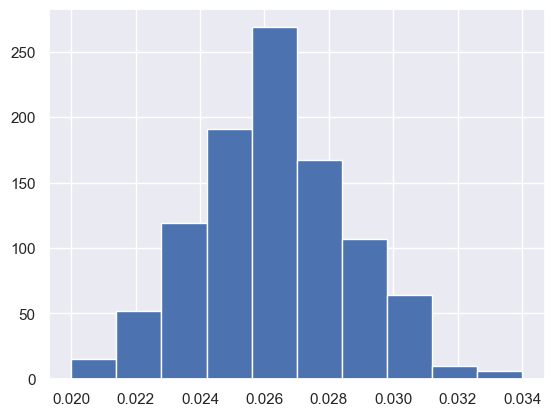

In [16]:
validation_set_error = [] 
for i in range(1,1001): 
    design = MS(['income', 'balance']) 
    X = design.fit_transform(default) 
    y = default['default'] == 'Yes' 
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=i)
    results = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit() 
    pred_proba = results.predict(X_valid) 
    pred = np.where(pred_proba > 0.5, 1, 0) 
    conf_mat = confusion_table(pred, y_valid) 
    error_rate = (conf_mat.iloc[0, 1]+ conf_mat.iloc[1, 0])/conf_mat.sum().sum() 
    validation_set_error.append(error_rate) 
validation_set_error_df = pd.DataFrame(validation_set_error) 
print(validation_set_error_df.describe()) 
plt.hist(validation_set_error_df) 
plt.show() 


                 0
count  1000.000000
mean      0.026644
std       0.002402
min       0.020333
25%       0.025000
50%       0.026667
75%       0.028333
max       0.034333


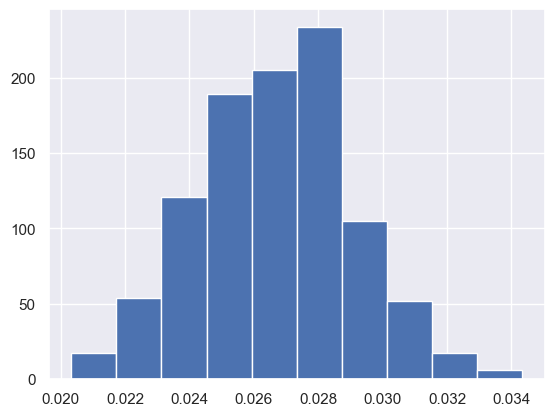

In [18]:
validation_set_error = [] 
for i in range(1,1001): 
    design = MS(['income', 'balance','student']) 
    X = design.fit_transform(default) 
    y = default['default'] == 'Yes' 
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=i)
    results = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit() 
    pred_proba = results.predict(X_valid) 
    pred = np.where(pred_proba > 0.5, 1, 0) 
    conf_mat = confusion_table(pred, y_valid) 
    error_rate = (conf_mat.iloc[0, 1]+ conf_mat.iloc[1, 0])/conf_mat.sum().sum() 
    validation_set_error.append(error_rate) 
validation_set_error_df = pd.DataFrame(validation_set_error) 
print(validation_set_error_df.describe()) 
plt.hist(validation_set_error_df) 
plt.show() 


In [19]:
design = MS(['income', 'balance']) 
X = design.fit_transform(default) 
y = default['default'] == 'Yes' 
lr = sm.GLM(y, X, family=sm.families.Binomial()) 
results = lr.fit() 
summarize(results)


,coef,std err,z,P>|z|
intercept,-11.540500,0.435000,-26.544,0.0
income,0.000021,0.000005,4.174,0.0
balance,0.005600,0.000000,24.835,0.0


In [20]:
def boot_fn(df: pd.DataFrame, idx: np.ndarray): 
    design = MS(['income', 'balance'])
    data = df.loc[idx] 
    X = design.fit_transform(data) 
    y = data['default'] == 'Yes' 
    lr = sm.GLM(y, X, family=sm.families.Binomial()) 
    results = lr.fit() 
    return results.params.loc[['income', 'balance']] 


In [21]:
def boot_SE(func, D, n=None, B=1000, seed=0): 
    rng = np.random.default_rng(seed) 
    first_, second_ = 0, 0 
    n = n or D.shape[0] 
    for _ in range(B): 
        idx = rng.choice(D.index, n, replace=True) 
        value = func(D, idx) 
        first_ += value 
        second_ += value**2 
    return np.sqrt(second_ / B - (first_ / B)**2) 
params_SE = boot_SE(boot_fn, default, B=1000, seed=0) 
params_SE


income     0.000005
balance    0.000230
dtype: float64

In [24]:
print(results.bse.__str__().split('\n')[1:]) 
print(params_SE.__str__().split('\n')) 
np.abs(results.bse[1:] - params_SE)


['income       0.000005', 'balance      0.000227', 'dtype: float64']
['income     0.000005', 'balance    0.000230', 'dtype: float64']


income     2.180457e-07
balance    3.053959e-06
dtype: float64